In [1]:
import torch

print("PyTorch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version : 2.10.0+cu128
CUDA Available : True
GPU Name : Tesla T4


In [2]:
###############################################
# IMPORT LIBRARIES
###############################################

import os
import copy
import json
import random
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split
)

from torchvision.datasets import ImageFolder
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [3]:
###############################################
# CONFIGURATION
###############################################

SEED = 42

IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 25

LEARNING_RATE = 1e-3

NUM_WORKERS = 2

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

Device : cuda


In [4]:
###############################################
# REPRODUCIBILITY
###############################################

def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print("Seed Set Successfully")

Seed Set Successfully


In [5]:
###############################################
# CREATE DIRECTORIES
###############################################

ARTIFACTS_DIR = "artifacts"

MODELS_DIR = os.path.join(
    ARTIFACTS_DIR,
    "models"
)

PLOTS_DIR = os.path.join(
    ARTIFACTS_DIR,
    "plots"
)

REPORTS_DIR = os.path.join(
    ARTIFACTS_DIR,
    "reports"
)

HISTORY_DIR = os.path.join(
    ARTIFACTS_DIR,
    "history"
)

CHECKPOINTS_DIR = os.path.join(
    ARTIFACTS_DIR,
    "checkpoints"
)

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

print("Directories Created Successfully")

Directories Created Successfully


In [6]:
###############################################
# HELPER FUNCTIONS
###############################################

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


def save_history(history, file_name):

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        os.path.join(
            HISTORY_DIR,
            file_name + ".csv"
        ),
        index=False
    )


def save_json(data, file_name):

    with open(
        os.path.join(
            HISTORY_DIR,
            file_name + ".json"
        ),
        "w"
    ) as f:

        json.dump(
            data,
            f,
            indent=4
        )


def save_pickle(data, file_name):

    joblib.dump(
        data,
        os.path.join(
            HISTORY_DIR,
            file_name + ".pkl"
        )
    )


print("Helper Functions Ready")

Helper Functions Ready


In [7]:
###############################################
# RAW TRANSFORMS
###############################################

raw_train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

raw_test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

print("Raw Transforms Ready")

Raw Transforms Ready


In [8]:
###############################################
# AUGMENTED TRANSFORMS
###############################################

augmented_train_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        IMAGE_SIZE
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(
        p=0.2
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(

        brightness=0.2,

        contrast=0.2,

        saturation=0.2,

        hue=0.1

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]

    )

])

print("Augmented Transforms Ready")

Augmented Transforms Ready


In [9]:
###############################################
# VERIFY TRANSFORMS EXIST
###############################################

if "raw_train_transform" not in globals():

    raw_train_transform = transforms.Compose([

        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    ])


if "raw_test_transform" not in globals():

    raw_test_transform = transforms.Compose([

        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    ])


print("Transforms verified")

Transforms verified


In [10]:
###############################################
# LOAD COMPLETE DATASET
###############################################

from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

full_dataset = ImageFolder(
    root="/kaggle/input/datasets/gamingandtechgt/animals-10/raw-img",
    transform=None
)

class_names = full_dataset.classes
num_classes = len(class_names)

dataset_size = len(full_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Classes : {class_names}")
print(f"Number of Classes : {num_classes}")

print(f"Total Images : {dataset_size}")
print(f"Training : {len(train_dataset)}")
print(f"Validation : {len(val_dataset)}")
print(f"Testing : {len(test_dataset)}")

Classes : ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Number of Classes : 10
Total Images : 26179
Training : 18325
Validation : 3926
Testing : 3928


In [11]:
###############################################
# DATASET WRAPPER
###############################################

class CustomSubset(Dataset):

    def __init__(self, subset, transform=None):

        self.subset = subset
        self.transform = transform

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        if self.transform is not None:

            image = self.transform(image)

        return image, label

In [12]:
###############################################
# RAW DATASET
###############################################

raw_train_dataset = CustomSubset(
    train_dataset,
    transform=raw_train_transform
)

raw_val_dataset = CustomSubset(
    val_dataset,
    transform=raw_test_transform
)

raw_test_dataset = CustomSubset(
    test_dataset,
    transform=raw_test_transform
)

print("Raw Dataset Ready")

Raw Dataset Ready


In [13]:
###############################################
# AUGMENTED DATASET
###############################################

aug_train_dataset = CustomSubset(
    train_dataset,
    transform=augmented_train_transform
)

aug_val_dataset = CustomSubset(
    val_dataset,
    transform=raw_test_transform
)

aug_test_dataset = CustomSubset(
    test_dataset,
    transform=raw_test_transform
)

print("Augmented Dataset Ready")

Augmented Dataset Ready


In [14]:
###############################################
# RAW DATALOADERS
###############################################

raw_train_loader = DataLoader(
    raw_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

raw_val_loader = DataLoader(
    raw_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

raw_test_loader = DataLoader(
    raw_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Raw DataLoaders Ready")

Raw DataLoaders Ready


In [15]:
###############################################
# AUGMENTED DATALOADERS
###############################################

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

aug_val_loader = DataLoader(
    aug_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

aug_test_loader = DataLoader(
    aug_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Augmented DataLoaders Ready")

Augmented DataLoaders Ready


In [16]:
###############################################
# DATASET INFORMATION
###############################################

print("=" * 60)
print("RAW DATASET")
print("=" * 60)

print(f"Training Images : {len(raw_train_dataset)}")
print(f"Validation Images : {len(raw_val_dataset)}")
print(f"Testing Images : {len(raw_test_dataset)}")

print()

print("=" * 60)
print("AUGMENTED DATASET")
print("=" * 60)

print(f"Training Images : {len(aug_train_dataset)}")
print(f"Validation Images : {len(aug_val_dataset)}")
print(f"Testing Images : {len(aug_test_dataset)}")

RAW DATASET
Training Images : 18325
Validation Images : 3926
Testing Images : 3928

AUGMENTED DATASET
Training Images : 18325
Validation Images : 3926
Testing Images : 3928


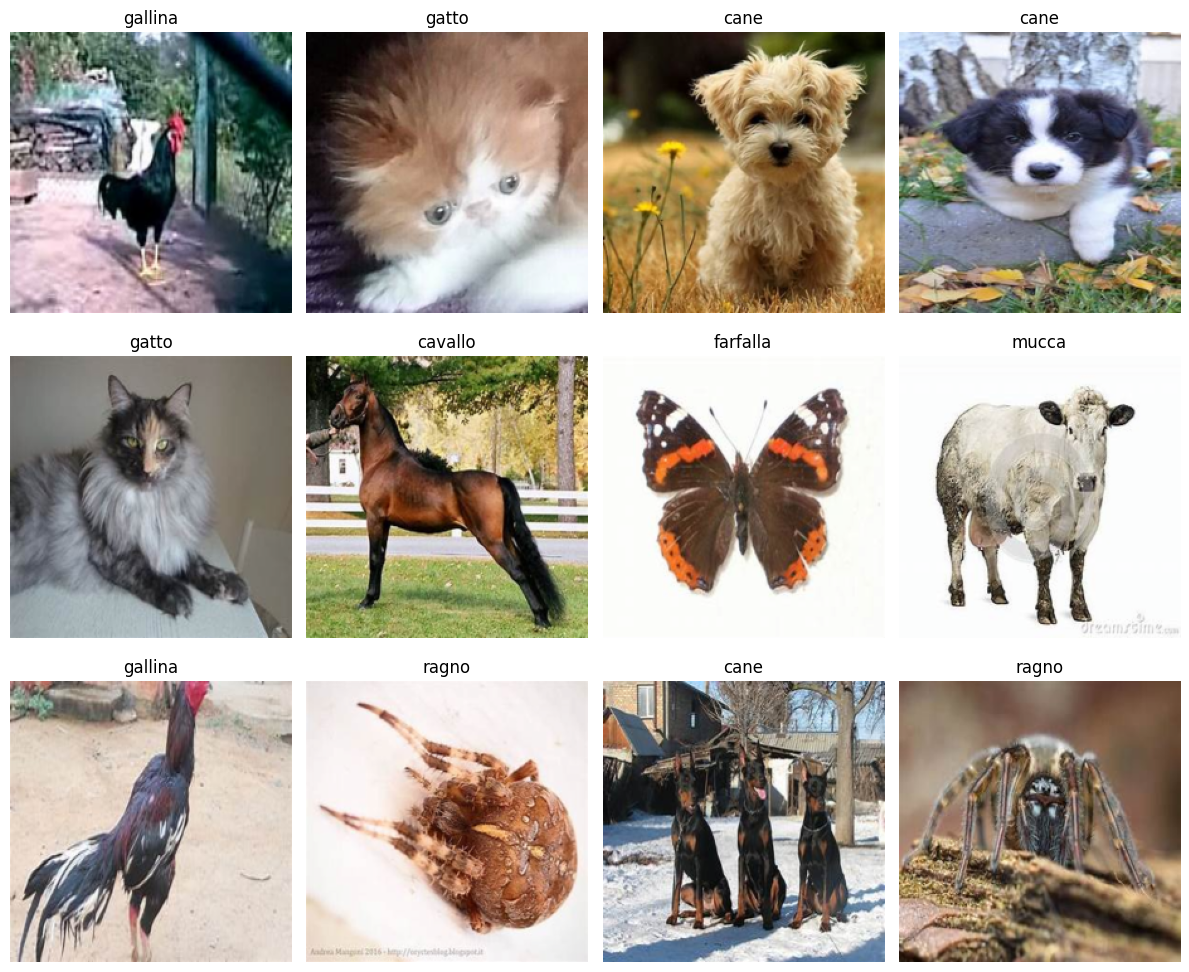

In [17]:
###############################################
# VISUALIZE TRAINING IMAGES
###############################################

images, labels = next(iter(raw_train_loader))

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(12):

    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOTS_DIR,
        "sample_training_images.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
class MiniCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,num_classes)

        )


    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [46]:
class LeNet(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))

        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,num_classes)

        )


    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [44]:
class AlexNet(nn.Module):

    def __init__(self,num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,64,11,stride=4,padding=2),
            nn.ReLU(),
            nn.MaxPool2d(3,2),

            nn.Conv2d(64,192,5,padding=2),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(3,2),

            nn.Conv2d(192,384,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(384,256,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(256,256,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(3,2),

            nn.AdaptiveAvgPool2d((1,1))

        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256,128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128,num_classes)

        )


    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [79]:
vgg16 = models.vgg16(weights="IMAGENET1K_V1")


for param in vgg16.parameters():
    param.requires_grad = False


vgg16.classifier[6] = nn.Linear(
    4096,
    num_classes
)


for param in vgg16.classifier[6].parameters():
    param.requires_grad = True

In [80]:
###############################################
# WEIGHT INITIALIZATION
###############################################

def initialize_weights(model):

    for m in model.modules():

        if isinstance(m, nn.Conv2d):

            nn.init.kaiming_normal_(
                m.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.Linear):

            nn.init.xavier_uniform_(m.weight)

            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.BatchNorm2d):

            nn.init.constant_(m.weight, 1)

            nn.init.constant_(m.bias, 0)

print("Weight initialization function created successfully.")

Weight initialization function created successfully.


In [81]:
mini_cnn = MiniCNN(num_classes)

lenet = LeNet(num_classes)

alexnet = AlexNet(num_classes)

initialize_weights(mini_cnn)
initialize_weights(lenet)
initialize_weights(alexnet)


mini_cnn = mini_cnn.to(DEVICE)
lenet = lenet.to(DEVICE)
alexnet = alexnet.to(DEVICE)
vgg16 = vgg16.to(DEVICE)

print("All models initialized successfully.")

All models initialized successfully.


In [82]:
print(count_parameters(vgg16))

for name,p in vgg16.named_parameters():
    if p.requires_grad:
        print(name)

40970
classifier.6.weight
classifier.6.bias


In [83]:
###############################################
# LOSS FUNCTION
###############################################

criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [84]:
###############################################
# OPTIMIZER
###############################################

def get_optimizer(model):

    return optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

In [85]:
###############################################
# LR SCHEDULER
###############################################

def get_scheduler(optimizer):

    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=2,
        min_lr=1e-6
    )

In [86]:
###############################################
# EARLY STOPPING
###############################################

class EarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience

        self.best_loss = np.inf

        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True

In [87]:
###############################################
# PLOT HISTORY
###############################################

def plot_history(history, model_name, experiment):

    fig, ax = plt.subplots(figsize=(8,5))

    ax.plot(
        history["train_loss"],
        label="Train Loss"
    )

    ax.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    ax.set_title(
        f"{model_name} ({experiment}) Loss"
    )

    ax.set_xlabel("Epoch")

    ax.set_ylabel("Loss")

    ax.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{model_name}_{experiment}_loss.png"
        ),
        dpi=300
    )

    plt.close()


    fig, ax = plt.subplots(figsize=(8,5))

    ax.plot(
        history["train_acc"],
        label="Train Accuracy"
    )

    ax.plot(
        history["val_acc"],
        label="Validation Accuracy"
    )

    ax.set_title(
        f"{model_name} ({experiment}) Accuracy"
    )

    ax.set_xlabel("Epoch")

    ax.set_ylabel("Accuracy")

    ax.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{model_name}_{experiment}_accuracy.png"
        ),
        dpi=300
    )

    plt.close()

In [88]:
###############################################
# TRAIN ONE EPOCH
###############################################

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        running_correct += (predicted == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [89]:
###############################################
# VALIDATE ONE EPOCH
###############################################

def validate_one_epoch(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader, leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            running_correct += (predicted == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [90]:
###############################################
# EVALUATE MODEL
###############################################

def evaluate_model(
    model,
    test_loader
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in tqdm(test_loader, leave=False):

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return (
        y_true,
        y_pred,
        acc,
        prec,
        rec,
        f1
    )

In [91]:
###############################################
# CONFUSION MATRIX
###############################################

def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    experiment
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(
        f"{model_name} ({experiment})"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{model_name}_{experiment}_confusion_matrix.png"
        ),
        dpi=300
    )

    plt.show()

In [92]:
###############################################
# COMPLETE TRAINING FUNCTION
###############################################

def train_model(
    model,
    train_loader,
    val_loader,
    model_name,
    experiment,
    epochs=EPOCHS
):

    optimizer = get_optimizer(model)

    scheduler = get_scheduler(optimizer)

    early_stopping = EarlyStopping(patience=5)

    history = {

        "train_loss": [],
        "val_loss": [],

        "train_acc": [],
        "val_acc": [],

        "learning_rate": []

    }

    best_val_loss = float("inf")

    best_epoch = 0

    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        print("="*60)
        print(f"{model_name} | {experiment}")
        print(f"Epoch {epoch+1}/{epochs}")
        print("="*60)

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = validate_one_epoch(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        history["learning_rate"].append(lr)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.4f}")

        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.4f}")

        print(f"LR         : {lr:.8f}")

        ####################################################
        # SAVE BEST MODEL
        ####################################################

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_epoch = epoch + 1

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_model_state,
                os.path.join(
                    MODELS_DIR,
                    f"{model_name}_{experiment}.pth"
                )
            )

            torch.save(

                {

                    "epoch": epoch + 1,

                    "model_state_dict": model.state_dict(),

                    "optimizer_state_dict": optimizer.state_dict(),

                    "scheduler_state_dict": scheduler.state_dict(),

                    "best_val_loss": best_val_loss

                },

                os.path.join(

                    CHECKPOINTS_DIR,

                    f"{model_name}_{experiment}_BEST.pt"

                )

            )

        ####################################################
        # SAVE LAST CHECKPOINT
        ####################################################

        torch.save(

            {

                "epoch": epoch + 1,

                "model_state_dict": model.state_dict(),

                "optimizer_state_dict": optimizer.state_dict(),

                "scheduler_state_dict": scheduler.state_dict(),

                "best_val_loss": best_val_loss

            },

            os.path.join(

                CHECKPOINTS_DIR,

                f"{model_name}_{experiment}_LAST.pt"

            )

        )

        ####################################################

        early_stopping(val_loss)

        if early_stopping.early_stop:

            print("\nEarly Stopping Triggered")

            break

    ########################################################

    model.load_state_dict(best_model_state)

    history["best_epoch"] = best_epoch

    history["best_val_loss"] = best_val_loss

    ########################################################

    save_history(
        history,
        f"{model_name}_{experiment}"
    )

    save_pickle(
        history,
        f"{model_name}_{experiment}"
    )

    plot_history(
        history,
        model_name,
        experiment
    )

    ########################################################

    all_history[
        f"{model_name}_{experiment}"
    ] = history

    print("\nTraining Finished")

    print(f"Best Epoch : {best_epoch}")

    print(f"Best Validation Loss : {best_val_loss:.4f}")

    return model, history

In [93]:
###############################################
# GLOBAL HISTORY DICTIONARY
###############################################

all_history = {}

results_df = pd.DataFrame(
    columns=[
        "Model",
        "Dataset",
        "Train Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("History Dictionary Ready")

History Dictionary Ready


In [94]:
###############################################
# SANITY CHECK
###############################################

print("="*60)
print("DEVICE")
print("="*60)
print(DEVICE)


print("\n" + "="*60)
print("DATASET CHECK")
print("="*60)

print("num_classes:", num_classes)
print("class_names:", class_names)

print("train size:", len(train_dataset))
print("val size:", len(val_dataset))
print("test size:", len(test_dataset))


print("\n" + "="*60)
print("DATALOADER CHECK")
print("="*60)

print("train batches:", len(raw_train_loader))
print("val batches:", len(raw_val_loader))
print("test batches:", len(raw_test_loader))


images, labels = next(iter(raw_train_loader))

print("\nImages:")
print("shape:", images.shape)
print("dtype:", images.dtype)
print("min:", images.min().item())
print("max:", images.max().item())

print("\nLabels:")
print("shape:", labels.shape)
print("dtype:", labels.dtype)
print("unique:", torch.unique(labels))
print("min:", labels.min().item())
print("max:", labels.max().item())


print("\n" + "="*60)
print("MODEL CHECK")
print("="*60)

print(mini_cnn)

outputs = mini_cnn(
    images.to(DEVICE)
)

print("\nOutput:")
print("shape:", outputs.shape)
print("dtype:", outputs.dtype)


print("\n" + "="*60)
print("PREDICTION CHECK")
print("="*60)

preds = outputs.argmax(dim=1)

print("predictions:", preds.cpu())
print("prediction distribution:")
print(torch.bincount(preds.cpu(), minlength=num_classes))


print("\n" + "="*60)
print("PARAMETER CHECK")
print("="*60)

total_params = sum(
    p.numel()
    for p in mini_cnn.parameters()
    if p.requires_grad
)

print("Trainable parameters:", total_params)

DEVICE
cuda

DATASET CHECK
num_classes: 10
class_names: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
train size: 18325
val size: 3926
test size: 3928

DATALOADER CHECK
train batches: 573
val batches: 123
test batches: 123

Images:
shape: torch.Size([32, 3, 224, 224])
dtype: torch.float32
min: -2.1179039478302
max: 2.640000104904175

Labels:
shape: torch.Size([32])
dtype: torch.int64
unique: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
min: 0
max: 9

MODEL CHECK
MiniCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
 

In [98]:
###############################################
# TRAIN MINICNN (RAW)
###############################################

mini_cnn = MiniCNN(num_classes)
initialize_weights(mini_cnn)
mini_cnn = mini_cnn.to(DEVICE)

mini_cnn, mini_raw_history = train_model(
    model=mini_cnn,
    train_loader=raw_train_loader,
    val_loader=raw_val_loader,
    model_name="MiniCNN",
    experiment="Raw",
    epochs=20
)

MiniCNN | Raw
Epoch 1/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.9734
Train Acc  : 0.3059
Val Loss   : 1.8048
Val Acc    : 0.3777
LR         : 0.00100000
MiniCNN | Raw
Epoch 2/20


  0%|          | 0/573 [00:00<?, ?it/s]

...

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.1664
Train Acc  : 0.5955
Val Loss   : 1.3118
Val Acc    : 0.5563
LR         : 0.00100000
MiniCNN | Raw
Epoch 20/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.1522
Train Acc  : 0.5991
Val Loss   : 1.0964
Val Acc    : 0.6263
LR         : 0.00100000

Training Finished
Best Epoch : 20
Best Validation Loss : 1.0964


In [100]:
###############################################
# TRAIN MINICNN (AUGMENTED)
###############################################

mini_cnn = MiniCNN(num_classes)
initialize_weights(mini_cnn)
mini_cnn = mini_cnn.to(DEVICE)

mini_cnn, mini_aug_history = train_model(
    model=mini_cnn,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    model_name="MiniCNN",
    experiment="Augmented",
    epochs=20
)

MiniCNN | Augmented
Epoch 1/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 2.1185
Train Acc  : 0.2456
Val Loss   : 2.0064
Val Acc    : 0.3034
LR         : 0.00100000
MiniCNN | Augmented
Epoch 2/20


  0%|          | 0/573 [00:00<?, ?it/s]

...

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.5518
Train Acc  : 0.4566
Val Loss   : 1.3440
Val Acc    : 0.5354
LR         : 0.00010000
MiniCNN | Augmented
Epoch 20/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.5354
Train Acc  : 0.4647
Val Loss   : 1.3401
Val Acc    : 0.5420
LR         : 0.00010000

Training Finished
Best Epoch : 20
Best Validation Loss : 1.3401


In [ ]:
###############################################
# TRAIN LENET (RAW)
###############################################

lenet = LeNet(num_classes)
initialize_weights(lenet)
lenet = lenet.to(DEVICE)

lenet, lenet_raw_history = train_model(
    model=lenet,
    train_loader=raw_train_loader,
    val_loader=raw_val_loader,
    model_name="LeNet",
    experiment="Raw",
    epochs=20
)

LeNet | Raw
Epoch 1/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Train Loss : 1.9955
Train Acc  : 0.2916
Val Loss   : 1.8442
Val Acc    : 0.3484
LR         : 0.00100000
LeNet | Raw
Epoch 2/20


...

  0%|          | 0/123 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss : 1.0825
Train Acc  : 0.6253
Val Loss   : 1.1498
Val Acc    : 0.6105
LR         : 0.00010000
LeNet | Raw
Epoch 20/20


  0%|          | 0/573 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

In [102]:
###############################################
# TRAIN LENET (AUGMENTED)
###############################################

lenet = LeNet(num_classes)
initialize_weights(lenet)
lenet = lenet.to(DEVICE)

lenet, lenet_aug_history = train_model(
    model=lenet,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    model_name="LeNet",
    experiment="Augmented",
    epochs=20
)

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 2.1189
Train Acc  : 0.2502
Val Loss   : 2.0067
Val Acc    : 0.2972
LR         : 0.00100000
LeNet | Augmented
Epoch 2/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 2.0493
Train Acc  : 0.2876
Val Loss   : 1.9470
Val Acc    : 0.3138
LR         : 0.00100000
LeNet | Augmented
Epoch 3/20


...

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.5544
Train Acc  : 0.4595
Val Loss   : 1.3982
Val Acc    : 0.5104
LR         : 0.00100000
LeNet | Augmented
Epoch 20/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.5461
Train Acc  : 0.4617
Val Loss   : 1.3016
Val Acc    : 0.5583
LR         : 0.00100000

Training Finished
Best Epoch : 20
Best Validation Loss : 1.3016


In [103]:
###############################################
# TRAIN ALEXNET (RAW)
###############################################

alexnet = AlexNet(num_classes)
initialize_weights(alexnet)
alexnet = alexnet.to(DEVICE)

alexnet, alex_raw_history = train_model(
    model=alexnet,
    train_loader=raw_train_loader,
    val_loader=raw_val_loader,
    model_name="AlexNet",
    experiment="Raw",
    epochs=20
)

AlexNet | Raw
Epoch 1/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0> 
  Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^^ ^^  ^ ^ ^ ^ ^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^^  ^ ^ 
   File "/usr/lib

Train Loss : 2.1945
Train Acc  : 0.2261
Val Loss   : 2.1501
Val Acc    : 0.2366
LR         : 0.00100000
AlexNet | Raw
Epoch 2/20


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
         Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0> ^
Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^^    self._shutdown_workers()^^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():^
^ ^ ^ ^ ^ ^Exceptio

Train Loss : 0.3296
Train Acc  : 0.8868
Val Loss   : 0.9471
Val Acc    : 0.7338
LR         : 0.00001000
AlexNet | Raw
Epoch 20/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 0.2996
Train Acc  : 0.8978
Val Loss   : 0.9438
Val Acc    : 0.7318
LR         : 0.00001000

Training Finished
Best Epoch : 16
Best Validation Loss : 0.8877


In [104]:
###############################################
# TRAIN ALEXNET (AUGMENTED)
###############################################

alexnet = AlexNet(num_classes)
initialize_weights(alexnet)
alexnet = alexnet.to(DEVICE)

alexnet, alex_aug_history = train_model(
    model=alexnet,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    model_name="AlexNet",
    experiment="Augmented",
    epochs=20
)

AlexNet | Augmented
Epoch 1/20


  0%|          | 0/573 [00:00<?, ?it/s]

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 2.2287
Train Acc  : 0.1917
Val Loss   : 2.1447
Val Acc    : 0.2453
LR         : 0.00100000
AlexNet | Augmented
Epoch 2/20


  0%|          | 0/573 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b7d99ab6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/123 [00:00<?, ?it/s]

Train Loss : 1.7887
Train Acc  : 0.3774
Val Loss   : 1.5875
Val Acc    : 0.4440
LR         : 0.00100000
AlexNet | Augmented
Epoch 11/20


  0%|          | 0/573 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
for name,p in vgg16.named_parameters():
    if p.requires_grad:
        print(name)

In [ ]:
###############################################
# TRAIN VGG16 (RAW)
###############################################

vgg16 = models.vgg16(
    weights="IMAGENET1K_V1"
)


# freeze all layers

for param in vgg16.parameters():
    param.requires_grad = False


# replace classifier

vgg16.classifier[6] = nn.Linear(
    4096,
    num_classes
)


# train only last layer

for param in vgg16.classifier[6].parameters():
    param.requires_grad = True


vgg16 = vgg16.to(DEVICE)


vgg16, vgg_raw_history = train_model(
    model=vgg16,
    train_loader=raw_train_loader,
    val_loader=raw_val_loader,
    model_name="VGG16",
    experiment="Raw",
    epochs=EPOCHS
)

In [ ]:
###############################################
# TRAIN VGG16 (AUGMENTED)
###############################################

vgg16 = models.vgg16(
    weights="IMAGENET1K_V1"
)


for param in vgg16.parameters():
    param.requires_grad = False


vgg16.classifier[6] = nn.Linear(
    4096,
    num_classes
)


for param in vgg16.classifier[6].parameters():
    param.requires_grad = True


vgg16 = vgg16.to(DEVICE)


vgg16, vgg_aug_history = train_model(
    model=vgg16,
    train_loader=aug_train_loader,
    val_loader=aug_val_loader,
    model_name="VGG16",
    experiment="Augmented",
    epochs=EPOCHS
)

In [105]:
import os

for root, dirs, files in os.walk("artifacts"):
    print(f"\n{root}")
    for f in files:
        size = os.path.getsize(os.path.join(root, f)) / (1024 * 1024)
        print(f"  {f:<40} {size:.2f} MB")


artifacts

artifacts/models
  MiniCNN_Raw.pth                          0.40 MB
  LeNet_Augmented.pth                      0.53 MB
  AlexNet_Raw.pth                          9.56 MB
  MiniCNN_Augmented.pth                    0.40 MB
  AlexNet_Augmented.pth                    9.56 MB
  LeNet_Raw.pth                            0.53 MB

artifacts/reports

artifacts/checkpoints
  LeNet_Raw_LAST.pt                        1.59 MB
  MiniCNN_Augmented_LAST.pt                1.20 MB
  LeNet_Augmented_BEST.pt                  1.59 MB
  MiniCNN_Augmented_BEST.pt                1.20 MB
  AlexNet_Augmented_BEST.pt                28.68 MB
  LeNet_Augmented_LAST.pt                  1.59 MB
  AlexNet_Augmented_LAST.pt                28.68 MB
  AlexNet_Raw_BEST.pt                      28.68 MB
  LeNet_Raw_BEST.pt                        1.59 MB
  MiniCNN_Raw_LAST.pt                      1.20 MB
  MiniCNN_Raw_BEST.pt                      1.20 MB
  AlexNet_Raw_LAST.pt                      28.68 MB

artifa

In [106]:
import shutil

shutil.make_archive(
    "animals10_artifacts",
    "zip",
    "artifacts"
)

print("ZIP created successfully!")

ZIP created successfully!
